In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from skimage.feature import hog
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [26]:
# --- Configuration ---
BASE_PATH = "/kaggle/input/datasets/aibloy/fairface/FairFace/"
SUBSET_SIZE = 1000
IMG_SIZE = (128, 128)

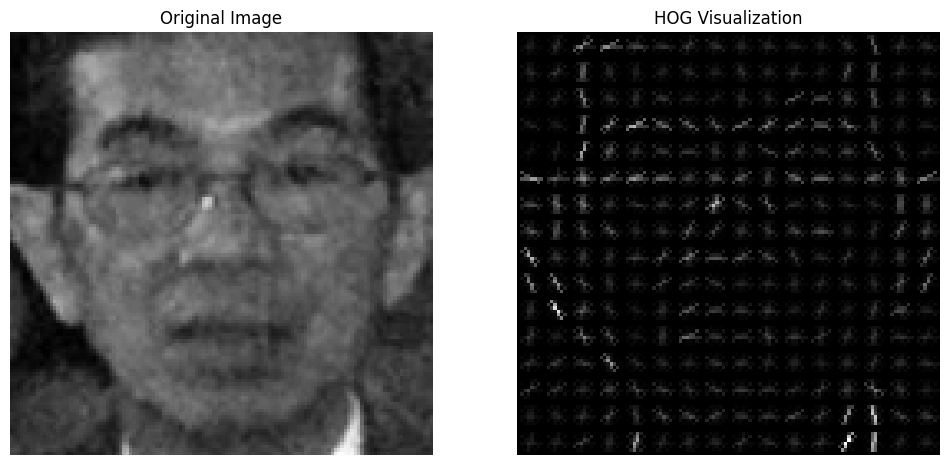

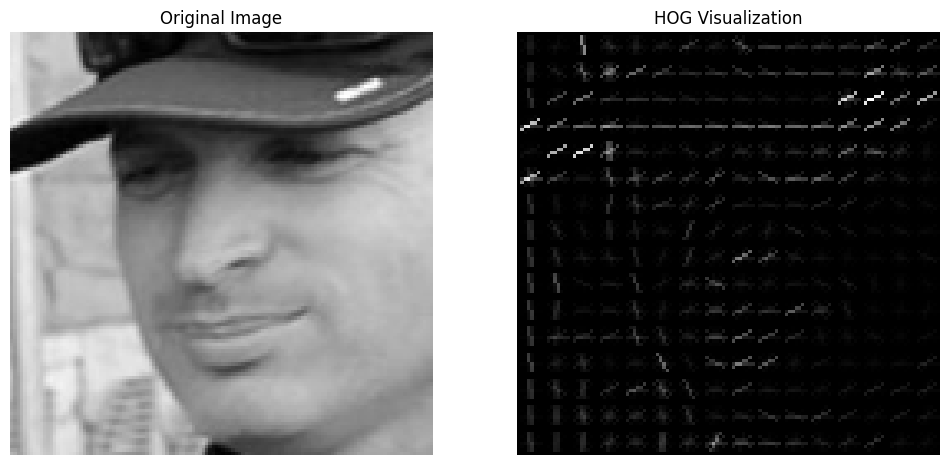

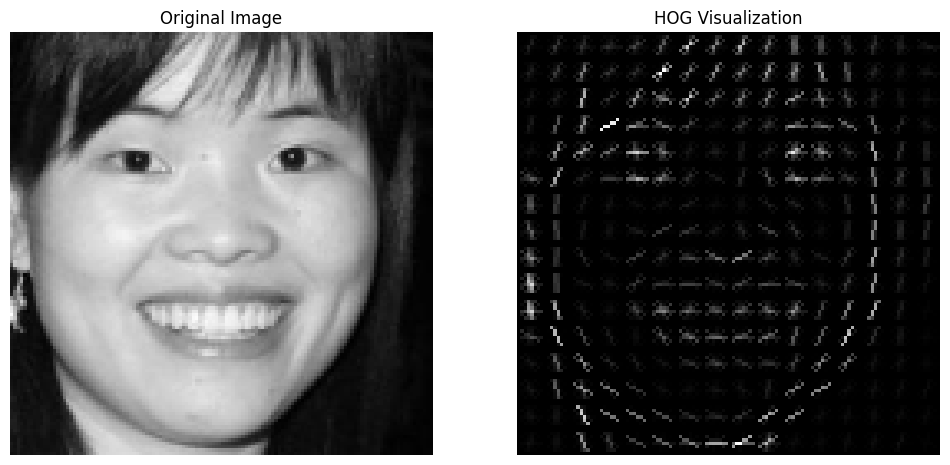

In [27]:
def extract_hog_features(img_path):
    # Load in grayscale as HOG doesn't require color
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Image not found.")
        return None
    img = cv2.resize(img, IMG_SIZE)
    
    # HOG parameters
    features, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), visualize=True)
    return features, hog_image

def visualize_hog_example(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG_SIZE)
    
    features, hog_image = extract_hog_features(img_path)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

    ax1.axis('off')
    ax1.imshow(img, cmap=plt.cm.gray)
    ax1.set_title('Original Image')

    ax2.axis('off')
    ax2.imshow(hog_image, cmap=plt.cm.gray)
    ax2.set_title('HOG Visualization')
    plt.show()

# Visualize a few examples
examples = ["train/1.jpg", "train/10.jpg", "train/100.jpg"]
for ex in examples:
    visualize_hog_example(os.path.join(BASE_PATH, ex))

In [30]:
def prepare_data(csv_file, subset_n):
    df = pd.read_csv(os.path.join(BASE_PATH, csv_file))
    
    # Create a combined key to balance across all attributes
    df['combined_group'] = df['age'].astype(str) + "_" + df['gender'].astype(str) + "_" + df['race'].astype(str)
    
    # Determine how many to take per unique combination
    # FairFace has 9 (age) * 2 (gender) * 7 (race) = 126 possible combinations
    unique_groups = df['combined_group'].nunique()
    samples_per_group = max(1, subset_n // unique_groups)
    
    # Stratified sampling on the combined key
    df_balanced = df.groupby('combined_group', group_keys=False).apply(
        lambda x: x.sample(min(len(x), samples_per_group), random_state=42)
    )
    
    # If we ended up with fewer than subset_n, fill the rest with random samples
    if len(df_balanced) < subset_n:
        remaining_n = subset_n - len(df_balanced)
        remaining_df = df.drop(df_balanced.index).sample(remaining_n, random_state=42)
        df_balanced = pd.concat([df_balanced, remaining_df])

    # Shuffle for the training process
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
    
    features_list = []
    labels = {'age': [], 'gender': [], 'race': []}
    
    print(f"Processing {len(df_balanced)} images...")
    
    for _, row in df_balanced.iterrows():
        full_path = os.path.join(BASE_PATH, row['file'])
        feat_tuple = extract_hog_features(full_path)
        
        if feat_tuple is not None:
            feat, _ = feat_tuple
            features_list.append(feat)
            labels['age'].append(row['age'])
            labels['gender'].append(row['gender'])
            labels['race'].append(row['race'])
            
    return np.array(features_list), labels

# Load and Preprocess
X, y_raw = prepare_data('train_labels.csv', SUBSET_SIZE)

X_train, X_test, y_train_age, y_test_age, y_train_gen, y_test_gen, y_train_race, y_test_race = train_test_split(
    X, 
    y_raw['age'], 
    y_raw['gender'], 
    y_raw['race'],
    test_size=0.2, 
    random_state=42,
    stratify=y_raw['race']
)

y_train = {'age': y_train_age, 'gender': y_train_gen, 'race': y_train_race}
y_test = {'age': y_test_age, 'gender': y_test_gen, 'race': y_test_race}

print(f"Train size: {len(X_train)}")
print(f"Test size:: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and Evaluate for each target
targets = ['age', 'gender', 'race']
classifiers = {}

for target in targets:
    print(f"\n--- Training k-NN for: {target.upper()} ---")
    
    # Encode labels
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train[target])
    y_test_encoded = le.transform(y_test[target])
    
    # Initialize k-NN
    knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn.fit(X_train_scaled, y_train_encoded)
    
    # Predict
    preds = knn.predict(X_test_scaled)
    
    print(f"Accuracy: {accuracy_score(y_test_encoded, preds):.2f}")
    print(classification_report(y_test_encoded, preds, target_names=le.classes_))
    
    classifiers[target] = knn

/tmp/ipykernel_55/2300392373.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = df.groupby('combined_group', group_keys=False).apply(


Processing 1000 images...
Train size: 800
Test size:: 200

--- Training k-NN for: AGE ---
Accuracy: 0.21
              precision    recall  f1-score   support

         0-2       0.42      0.52      0.47        21
       10-19       0.43      0.09      0.14        35
       20-29       0.25      0.22      0.23        23
         3-9       0.18      0.17      0.17        18
       30-39       0.20      0.20      0.20        25
       40-49       0.23      0.17      0.19        18
       50-59       0.17      0.04      0.07        24
       60-69       0.15      0.50      0.24        22
more than 70       0.07      0.07      0.07        14

    accuracy                           0.21       200
   macro avg       0.23      0.22      0.20       200
weighted avg       0.25      0.21      0.20       200


--- Training k-NN for: GENDER ---
Accuracy: 0.61
              precision    recall  f1-score   support

      Female       0.62      0.50      0.55        96
        Male       0.61      0.